# 🏢 High-Conviction Company Network Analysis
**Project Phase 2: Refined Pipeline**

This notebook constructs a financial network by mapping shared 'High-Conviction' institutional investments (Top 15 holdings).

---

## 🧩 Network Representation & Research Context

### 1. What is the Network Representation?
This project uses a **One-Mode Projection of a Bipartite Network**.
*   **The Buried Data**: The raw SEC data is bipartite (two-mode), consisting of *Investors* and *Companies*. Edges only exist between an investor and a company.
*   **The Nodes**: In this representation, nodes are **Publicly Traded Companies** (e.g., Apple, NVIDIA, JPMorgan).
*   **The Edges**: An undirected edge exists between two companies if they both appear in the **Top 15 holdings** of at least one institutional investor. This is a **Co-Investment Network**.
*   **The Filter**: We use a "High-Conviction" filter (Top 15 only) to eliminate the noise of broad index tracking and focus on the strategic core of the market.

### 2. How was it built? (Pipeline Workflow)
1.  **Data Acquisition**: We fetch **13F-HR filings** from the SEC API. We limit this to the most recent filings for a representative sample of the market.
2.  **Local Enrichment**: We match the companies found in the 13F filings with **local SEC submission JSONs**. This allows us to assign an industry sector (SEC Office) and SIC description to each node without additional API calls.
3.  **Filtering & Projection**: We remove companies that couldn't be enriched and build edges between the remaining companies based on shared investors.
4.  **LCC Extraction**: We extract the **Largest Connected Component (LCC)** to ensure the graph is a single contiguous structure, which is required for valid path-length and diameter calculations.

### 3. What research questions can this graph answer?
*   **Centrality**: Which companies act as the "Global Backbone" of institutional portfolios (High Degree Centrality)?
*   **Bridges**: Which companies act as "Linchpins" between different sectors, like Tech and Finance (High Betweenness Centrality)?
*   **Modularity**: Do investors cluster their high-conviction bets within specific industries, or do they diversify across the network (Community Detection)?
*   **Topology**: Is the US stock market structure **Scale-Free**? Does it follow a power-law degree distribution similar to the Barabási-Albert model?

---


In [52]:
import time
import os
import json
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sec_api import Form13FHoldingsApi
from collections import defaultdict
from community import community_louvain

# CONFIGURATION
API_KEY = 'apikey'
SUBMISSIONS_DIR = '/Users/cristianpop/Downloads/submissions'
CACHE_FILE = 'holdings_cache.json'
NUM_API_CALLS = 4

form13f = Form13FHoldingsApi(api_key=API_KEY)

## Step 1: Data Acquisition (13F-HR Filings)
We fetch institutional holdings. We use a local cache to avoid hitting API rate limits (429 errors) on repeat runs.

In [53]:
company_name_to_cik = {}
investor_top_holdings = {}

if os.path.exists(CACHE_FILE):
    print(f"Loading data from cache: {CACHE_FILE}")
    with open(CACHE_FILE, 'r') as f:
        cache = json.load(f)
        company_name_to_cik = cache.get('name_to_cik', {})
        investor_top_holdings = cache.get('holdings', {})
else:
    print(f"Fetching fresh data from SEC API ({NUM_API_CALLS} calls)...")
    try:
        for i in range(NUM_API_CALLS):
            print(f"  Executing Call {i+1}/{NUM_API_CALLS}...")
            query = {
                "query": 'formType:"13F-HR"',
                "from": str(i * 50),
                "size": "50",
                "sort": [{"filedAt": {"order": "desc"}}]
            }
            response = form13f.get_data(query)
            filings = response.get("data", [])
            
            for f in filings:
                name = f.get("companyName")
                holdings = f.get("holdings", [])
                # Filter for Top 15 holdings by value
                sorted_holdings = sorted(holdings, key=lambda x: x.get('value', 0), reverse=True)
                top_15 = []
                for h in sorted_holdings[:15]:
                    issuer = h.get("nameOfIssuer")
                    cik = h.get("cik")
                    if issuer and cik:
                        clean_name = issuer.strip().upper()
                        top_15.append(clean_name)
                        company_name_to_cik[clean_name] = cik
                
                if name and len(top_15) >= 5:
                    investor_top_holdings[name] = top_15
        
        # Save to cache
        with open(CACHE_FILE, 'w') as f:
            json.dump({'holdings': investor_top_holdings, 'name_to_cik': company_name_to_cik}, f)
            
    except Exception as e:
        print(f"ERROR: API request failed. Using available data. {e}")

unique_companies = list(company_name_to_cik.keys())
print(f"Found {len(investor_top_holdings)} investors and {len(unique_companies)} unique companies.")

Loading data from cache: holdings_cache.json
Found 187 investors and 968 unique companies.


## Step 2: Local Enrichment (SIC/Sector Mapping)
We match the identified companies with local SEC submission files to determine their industrial sector.

In [54]:
# 1. Load SIC mapping helpers
sic_lookup = {}
industry_lookup = {}
try:
    sic_df = pd.read_csv('sic_codes.csv')
    # Clean column names
    sic_df.columns = [c.strip().replace('"', '') for c in sic_df.columns]
    sic_df['SIC'] = pd.to_numeric(sic_df['SIC'], errors='coerce')
    sic_df = sic_df.dropna(subset=['SIC'])
    
    sic_lookup = sic_df.set_index('SIC')['Office'].to_dict()
    industry_lookup = sic_df.set_index('SIC')['IndustryTitle'].to_dict()
    print(f"Loaded {len(sic_lookup)} SIC definitions from sic_codes.csv")
except Exception as e:
    print(f"WARNING: Could not load sic_codes.csv: {e}")

# 2. Perform filesystem lookup for metadata
print(f"Matching {len(unique_companies)} companies with local JSON submissions...")
company_metadata = {}

for comp_name in unique_companies:
    cik = company_name_to_cik.get(comp_name)
    if not cik: continue
    
    # SEC files are usually named CIK0000123456.json
    filename = f"CIK{str(cik).zfill(10)}.json"
    filepath = os.path.join(SUBMISSIONS_DIR, filename)
    
    if os.path.exists(filepath):
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
                sic_raw = data.get('sic')
                if sic_raw and str(sic_raw).isdigit():
                    sic_code = int(sic_raw)
                    office = sic_lookup.get(sic_code, "Other")
                    industry = industry_lookup.get(sic_code, data.get('sicDescription', 'Unknown'))
                    
                    # Only keep companies we can actually categorize meaningfully
                    if office != "Other":
                        company_metadata[comp_name] = {
                            'sector': office,
                            'industry': industry,
                            'cik': cik
                        }
        except:
            continue

print(f"Successfully enriched {len(company_metadata)} companies with industrial sectors.")

Loaded 444 SIC definitions from sic_codes.csv
Matching 968 companies with local JSON submissions...
Successfully enriched 586 companies with industrial sectors.


## Step 3: Network Construction
We build the network only using companies that have valid industrial metadata.

In [55]:
G = nx.Graph()

# Filter holdings to only include enriched companies
filtered_holdings = {}
for investor, holdings in investor_top_holdings.items():
    valid_comps = [c for c in holdings if c in company_metadata]
    if len(valid_comps) >= 2: # Need at least 2 to create an edge
        filtered_holdings[investor] = valid_comps
        # Add edges between all pairs in the top 15
        for i in range(len(valid_comps)):
            for j in range(i + 1, len(valid_comps)):
                G.add_edge(valid_comps[i], valid_comps[j])

# Attach metadata to nodes
nx.set_node_attributes(G, company_metadata)

# Extract the Largest Connected Component (LCC) for valid metric calculation
if G.number_of_nodes() > 0:
    lcc = max(nx.connected_components(G), key=len)
    G = G.subgraph(lcc).copy()
    print(f"Network built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")
else:
    print("ERROR: No connections found between enriched companies.")

Network built: 518 nodes, 5033 edges.


## Step 4: Network Analytics
Calculating the structural properties of the corporate backbone.

In [56]:
if G.number_of_nodes() > 0:
    print("--- GLOBAL METRICS ---")
    try:
        print(f"Average Path Length: {nx.average_shortest_path_length(G):.2f}")
        print(f"Network Diameter: {nx.diameter(G)}")
    except: 
        print("Path metrics unavailable.")
        
    print(f"Average Clustering Coeff: {nx.average_clustering(G):.4f}")
    
    print("\n--- TOP BRIDGE COMPANIES (Betweenness Centrality) ---")
    bc = nx.betweenness_centrality(G)
    top_bc = sorted(bc.items(), key=lambda x: x[1], reverse=True)[:10]
    for name, score in top_bc:
        sector = G.nodes[name].get('sector', 'Unknown')
        print(f"  {name:<30} | BC: {score:.4f} | {sector}")

    # Community detection
    partition = community_louvain.best_partition(G)
    print(f"\nDetected {len(set(partition.values()))} high-conviction clusters.")
else:
    print("Skipping metrics for empty graph.")

--- GLOBAL METRICS ---
Average Path Length: 2.51
Network Diameter: 6
Average Clustering Coeff: 0.8607

--- TOP BRIDGE COMPANIES (Betweenness Centrality) ---
  APPLE INC                      | BC: 0.1958 | Office of Technology
  JOHNSON & JOHNSON              | BC: 0.1322 | Office of Life Sciences
  NVIDIA CORPORATION             | BC: 0.1199 | Office of Manufacturing
  MICROSOFT CORP                 | BC: 0.1195 | Office of Technology
  AMAZON COM INC                 | BC: 0.0660 | Office of Trade & Services
  ALPHABET INC                   | BC: 0.0552 | Office of Technology
  JPMORGAN CHASE & CO            | BC: 0.0506 | Office of Finance
  AMAZON.COM INC                 | BC: 0.0474 | Office of Trade & Services
  MERCADOLIBRE INC               | BC: 0.0350 | Office of Trade & Services or Office of Energy & Transportation
  WESCO INTL INC                 | BC: 0.0343 | Office of Trade & Services

Detected 13 high-conviction clusters.


## Step 5: Visualization
Mapping the network with nodes colored by SEC Sector.

/var/folders/m7/r4x8qphn4fddnkv33c6rv5ww0000gn/T/ipykernel_91588/2361707316.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_sectors))


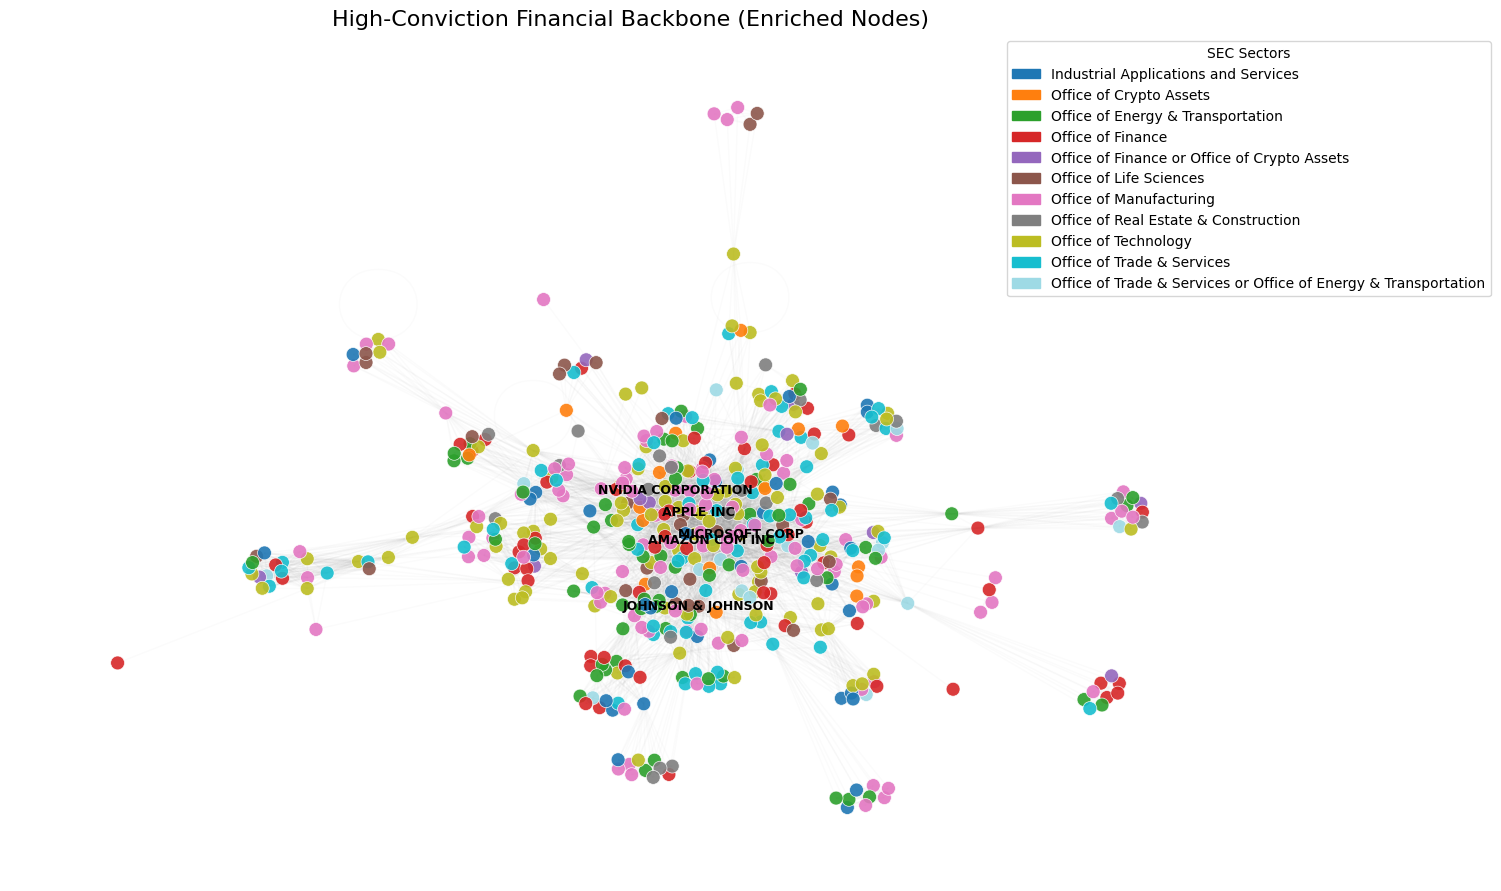

In [57]:
if G.number_of_nodes() > 0:
    import matplotlib.patches as mpatches
    
    plt.figure(figsize=(16, 11))
    pos = nx.spring_layout(G, k=0.2, iterations=50, seed=42)
    
    # Assign colors by sector
    sectors = nx.get_node_attributes(G, 'sector')
    unique_sectors = sorted(list(set(sectors.values())))
    cmap = plt.cm.get_cmap('tab20', len(unique_sectors))
    sector_to_color = {s: cmap(i) for i, s in enumerate(unique_sectors)}
    node_colors = [sector_to_color[sectors.get(n, 'Other')] for n in G.nodes()]
    
    # Draw edges and nodes
    nx.draw_networkx_edges(G, pos, alpha=0.03, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, node_size=100, node_color=node_colors, 
                           alpha=0.9, edgecolors='white', linewidths=0.5)
    
    # Label Top 5 most central nodes
    labels = {n: n for n, _ in top_bc[:5]}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold')
    
    # Legend
    legend_patches = [mpatches.Patch(color=sector_to_color[s], label=s) for s in unique_sectors]
    plt.legend(handles=legend_patches, title="SEC Sectors", loc='upper right', bbox_to_anchor=(1.2, 1))
    
    plt.title("High-Conviction Financial Backbone (Enriched Nodes)", fontsize=16)
    plt.axis('off')
    plt.show()
else:
    print("Visualization skipped: No data.")

## Step 6: Scale-Free Comparison
Comparing the real degree distribution against a Barabási-Albert random model.

Real Avg Path Length: 2.51
BA Model Avg Path Length: 2.42


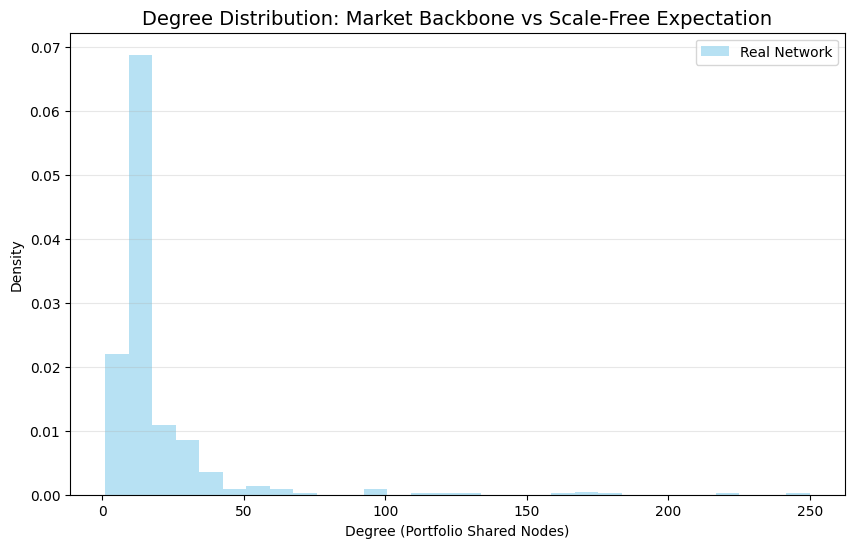

In [58]:
if G.number_of_nodes() > 10:
    n = G.number_of_nodes()
    m_avg = max(1, int(G.number_of_edges() / n))
    ba_ref = nx.barabasi_albert_graph(n, m_avg)
    
    print(f"Real Avg Path Length: {nx.average_shortest_path_length(G):.2f}")
    print(f"BA Model Avg Path Length: {nx.average_shortest_path_length(ba_ref):.2f}")
    
    plt.figure(figsize=(10, 6))
    real_degrees = [d for _, d in G.degree()]
    plt.hist(real_degrees, bins=30, density=True, alpha=0.6, color='skyblue', label='Real Network')
    plt.title("Degree Distribution: Market Backbone vs Scale-Free Expectation", fontsize=14)
    plt.xlabel("Degree (Portfolio Shared Nodes)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print("Graph too small for BA comparison.")

## Step 7: Data Export
Saving the processed network for external analysis (e.g., Gephi).

In [59]:
if G.number_of_nodes() > 0:
    # Save as GEXF
    nx.write_gexf(G, 'company_backbone.gexf')
    # Save as Edge List TXT
    nx.write_edgelist(G, 'company_backbone.txt', data=True)
    
    print("Files exported successfully:")
    print(" - company_backbone.gexf")
    print(" - company_backbone.txt")
else:
    print("No data to export.")

Files exported successfully:
 - company_backbone.gexf
 - company_backbone.txt
